# Exploratory Data Analysis



---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

# **1. Import packages**

In [4]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Plot style
sns.set_style("whitegrid")

%matplotlib inline

In [5]:
from google.colab import files

uploaded = files.upload()

Saving client_data.xlsx to client_data.xlsx


In [10]:
from google.colab import files

uploaded = files.upload()

Saving price_data.xlsx to price_data.xlsx


In [11]:
client_df = pd.read_excel("client_data.xlsx")
price_df = pd.read_excel("price_data.xlsx")

In [12]:
print("Client Data Shape:", client_df.shape)
print("Price Data Shape:", price_df.shape)

Client Data Shape: (14606, 26)
Price Data Shape: (193002, 8)


In [13]:
print("Client Data:")
display(client_df.head())

print("\nPrice Data:")
display(price_df.head())

Client Data:


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.000,0,0,1.780,0.114,0.098,40.607,t,0.000,25.440,25.440,2,678.990,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.950,0,0,16.270,0.146,0.000,44.311,f,0.000,16.380,16.380,1,18.890,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.960,0,0,38.720,0.166,0.088,44.311,f,0.000,28.600,28.600,1,6.600,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.040,0,0,19.830,0.147,0.000,44.311,f,0.000,30.220,30.220,1,25.460,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.750,526,0,131.730,0.117,0.100,40.607,f,52.320,44.910,44.910,1,47.980,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0



Price Data:


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151,0.000,0.000,44.267,0.000,0.000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151,0.000,0.000,44.267,0.000,0.000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151,0.000,0.000,44.267,0.000,0.000
3,038af19179925da21a25619c5a24b745,2015-04-01,0.150,0.000,0.000,44.267,0.000,0.000
4,038af19179925da21a25619c5a24b745,2015-05-01,0.150,0.000,0.000,44.267,0.000,0.000


In [14]:
display(client_df.tail())
display(price_df.tail())

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.010,0,0,18.570,0.138,0.000,44.311,t,0.000,27.880,27.880,2,381.770,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.690,181,0,144.030,0.100,0.092,58.996,f,15.940,0.000,0.000,1,90.340,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.390,179,0,129.600,0.117,0.100,40.607,f,18.050,39.840,39.840,1,20.380,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.340,0,0,7.180,0.146,0.000,44.311,f,0.000,13.080,13.080,1,0.960,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0
14605,563dde550fd624d7352f3de77c0cdfcd,MISSING,8730,0,0,2009-12-18,2016-12-17,2009-12-18,2015-12-21,762.410,0,0,1.070,0.167,0.088,45.311,f,0.000,11.840,11.840,1,96.340,6,ldkssxwpmemidmecebumciepifcamkci,10.392,0


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
192997,16f51cdc2baa19af0b940ee1b3dd17d5,2015-08-01,0.120,0.102,0.076,40.729,24.437,16.292
192998,16f51cdc2baa19af0b940ee1b3dd17d5,2015-09-01,0.120,0.102,0.076,40.729,24.437,16.292
192999,16f51cdc2baa19af0b940ee1b3dd17d5,2015-10-01,0.120,0.102,0.076,40.729,24.437,16.292
193000,16f51cdc2baa19af0b940ee1b3dd17d5,2015-11-01,0.120,0.102,0.076,40.729,24.437,16.292
193001,16f51cdc2baa19af0b940ee1b3dd17d5,2015-12-01,0.120,0.102,0.076,40.729,24.437,16.292


In [15]:
print("CLIENT DATA TYPES")
client_df.info()

CLIENT DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int6

In [16]:
print("\nPRICE DATA TYPES")
price_df.info()


PRICE DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  193002 non-null  object        
 1   price_date          193002 non-null  datetime64[ns]
 2   price_off_peak_var  193002 non-null  float64       
 3   price_peak_var      193002 non-null  float64       
 4   price_mid_peak_var  193002 non-null  float64       
 5   price_off_peak_fix  193002 non-null  float64       
 6   price_peak_fix      193002 non-null  float64       
 7   price_mid_peak_fix  193002 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 11.8+ MB


In [17]:
client_dtypes = pd.DataFrame({
    'Column': client_df.columns,
    'Data Type': client_df.dtypes.astype(str),
    'Missing Values': client_df.isnull().sum().values,
    'Unique Values': client_df.nunique().values
})

display(client_dtypes)

,Column,Data Type,Missing Values,Unique Values
id,id,object,0,14606
channel_sales,channel_sales,object,0,8
cons_12m,cons_12m,int64,0,11065
cons_gas_12m,cons_gas_12m,int64,0,2112
cons_last_month,cons_last_month,int64,0,4751
date_activ,date_activ,datetime64[ns],0,1796
date_end,date_end,datetime64[ns],0,368
date_modif_prod,date_modif_prod,datetime64[ns],0,2129
date_renewal,date_renewal,datetime64[ns],0,386
forecast_cons_12m,forecast_cons_12m,float64,0,13993


In [18]:
price_dtypes = pd.DataFrame({
    'Column': price_df.columns,
    'Data Type': price_df.dtypes.astype(str),
    'Missing Values': price_df.isnull().sum().values,
    'Unique Values': price_df.nunique().values
})

display(price_dtypes)

,Column,Data Type,Missing Values,Unique Values
id,id,object,0,16096
price_date,price_date,datetime64[ns],0,12
price_off_peak_var,price_off_peak_var,float64,0,1853
price_peak_var,price_peak_var,float64,0,1189
price_mid_peak_var,price_mid_peak_var,float64,0,711
price_off_peak_fix,price_off_peak_fix,float64,0,66
price_peak_fix,price_peak_fix,float64,0,31
price_mid_peak_fix,price_mid_peak_fix,float64,0,28


In [19]:
client_date_cols = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

for col in client_date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

price_df['price_date'] = pd.to_datetime(
    price_df['price_date'],
    errors='coerce'
)

In [20]:
client_df[client_date_cols].dtypes

,0
date_activ,datetime64[ns]
date_end,datetime64[ns]
date_modif_prod,datetime64[ns]
date_renewal,datetime64[ns]


In [21]:
price_df['price_date'].dtype

dtype('<M8[ns]')

In [22]:
client_missing = pd.DataFrame({
    'Missing Count': client_df.isnull().sum(),
    'Missing %': client_df.isnull().mean() * 100
})

client_missing = client_missing.sort_values(
    'Missing %',
    ascending=False
)

display(client_missing)

,Missing Count,Missing %
id,0,0.000
channel_sales,0,0.000
cons_12m,0,0.000
cons_gas_12m,0,0.000
cons_last_month,0,0.000
date_activ,0,0.000
date_end,0,0.000
date_modif_prod,0,0.000
date_renewal,0,0.000
forecast_cons_12m,0,0.000


In [23]:
price_missing = pd.DataFrame({
    'Missing Count': price_df.isnull().sum(),
    'Missing %': price_df.isnull().mean() * 100
})

price_missing = price_missing.sort_values(
    'Missing %',
    ascending=False
)

display(price_missing)

,Missing Count,Missing %
id,0,0.000
price_date,0,0.000
price_off_peak_var,0,0.000
price_peak_var,0,0.000
price_mid_peak_var,0,0.000
price_off_peak_fix,0,0.000
price_peak_fix,0,0.000
price_mid_peak_fix,0,0.000


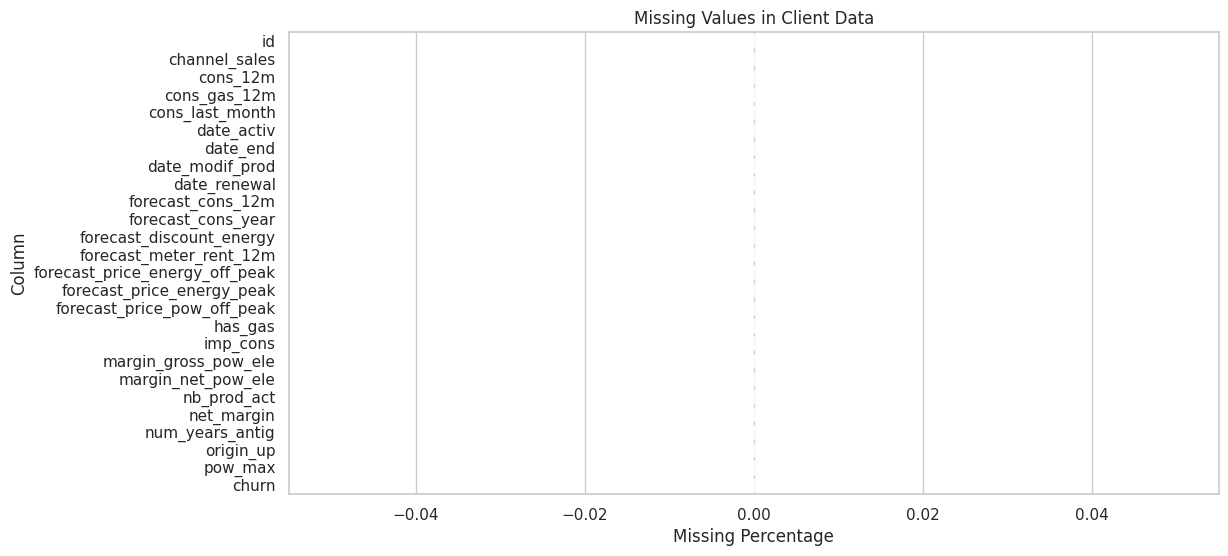

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=client_missing['Missing %'],
    y=client_missing.index
)

plt.title("Missing Values in Client Data")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.show()

In [25]:
print("Duplicate rows in client data:", client_df.duplicated().sum())
print("Duplicate rows in price data:", price_df.duplicated().sum())

Duplicate rows in client data: 0
Duplicate rows in price data: 0


In [26]:
print("Duplicate client IDs:",
      client_df['id'].duplicated().sum())

Duplicate client IDs: 0


In [27]:
client_df.describe(include='all').T
client_df.describe().T

,count,mean,min,25%,50%,75%,max,std
cons_12m,14606.000,159220.286,0.000,5674.750,14115.500,40763.750,6207104.000,573465.264
cons_gas_12m,14606.000,28092.375,0.000,0.000,0.000,0.000,4154590.000,162973.059
cons_last_month,14606.000,16090.270,0.000,0.000,792.500,3383.000,771203.000,64364.196
date_activ,14606,2011-01-28 07:54:18.879912448,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,2016-07-27 20:48:26.422018560,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,2013-01-02 12:29:10.951663872,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,2015-07-21 06:59:00.353279488,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.000,1868.615,0.000,494.995,1112.875,2401.790,82902.830,2387.572
forecast_cons_year,14606.000,1399.763,0.000,0.000,314.000,1745.750,175375.000,3247.786
forecast_discount_energy,14606.000,0.967,0.000,0.000,0.000,0.000,30.000,5.108


In [28]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161216,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.000,0.141,0.000,0.126,0.146,0.152,0.281,0.025
price_peak_var,193002.000,0.055,0.000,0.000,0.085,0.102,0.230,0.050
price_mid_peak_var,193002.000,0.030,0.000,0.000,0.000,0.073,0.114,0.036
price_off_peak_fix,193002.000,43.334,0.000,40.729,44.267,44.445,59.445,5.410
price_peak_fix,193002.000,10.623,0.000,0.000,0.000,24.340,36.491,12.842
price_mid_peak_fix,193002.000,6.410,0.000,0.000,0.000,16.226,17.458,7.774


In [29]:
unique_summary = pd.DataFrame({
    'Column': client_df.columns,
    'Unique Values': client_df.nunique(),
    'Data Type': client_df.dtypes.astype(str)
}).sort_values(
    'Unique Values'
)

display(unique_summary)

,Column,Unique Values,Data Type
churn,churn,2,int64
has_gas,has_gas,2,object
origin_up,origin_up,6,object
channel_sales,channel_sales,8,object
nb_prod_act,nb_prod_act,10,int64
forecast_discount_energy,forecast_discount_energy,12,int64
num_years_antig,num_years_antig,13,int64
forecast_price_pow_off_peak,forecast_price_pow_off_peak,41,float64
forecast_price_energy_peak,forecast_price_energy_peak,329,float64
date_end,date_end,368,datetime64[ns]


In [30]:
categorical_cols = client_df.select_dtypes(
    include=['object']
).columns

categorical_cols

Index(['id', 'channel_sales', 'has_gas', 'origin_up'], dtype='object')

In [31]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(client_df[col].value_counts(dropna=False).head(15))


--- id ---


,count
id,
563dde550fd624d7352f3de77c0cdfcd,1
24011ae4ebbe3035111d65fa7c15bc57,1
d29c2c54acc38ff3c0614d0a653813dd,1
764c75f661154dac3a6c254cd082ea7d,1
bba03439a292a1e166f80264c16191cb,1
149d57cf92fc41cf94415803a877cb4b,1
1aa498825382410b098937d65c4ec26d,1
7ab4bf4878d8f7661dfc20e9b8e18011,1
01495c955be7ec5e7f3203406785aae0,1



--- channel_sales ---


,count
channel_sales,
foosdfpfkusacimwkcsosbicdxkicaua,6754
MISSING,3725
lmkebamcaaclubfxadlmueccxoimlema,1843
usilxuppasemubllopkaafesmlibmsdf,1375
ewpakwlliwisiwduibdlfmalxowmwpci,893
sddiedcslfslkckwlfkdpoeeailfpeds,11
epumfxlbckeskwekxbiuasklxalciiuu,3
fixdbufsefwooaasfcxdxadsiekoceaa,2



--- has_gas ---


,count
has_gas,
f,11955
t,2651



--- origin_up ---


,count
origin_up,
lxidpiddsbxsbosboudacockeimpuepw,7097
kamkkxfxxuwbdslkwifmmcsiusiuosws,4294
ldkssxwpmemidmecebumciepifcamkci,3148
MISSING,64
usapbepcfoloekilkwsdiboslwaxobdp,2
ewxeelcelemmiwuafmddpobolfuxioce,1


# **Churn distribution**

In [32]:
churn_counts = client_df['churn'].value_counts()

display(churn_counts)

,count
churn,
0,13187
1,1419


In [33]:
churn_percentage = (
    client_df['churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(churn_percentage)

,proportion
churn,
0,90.280
1,9.720


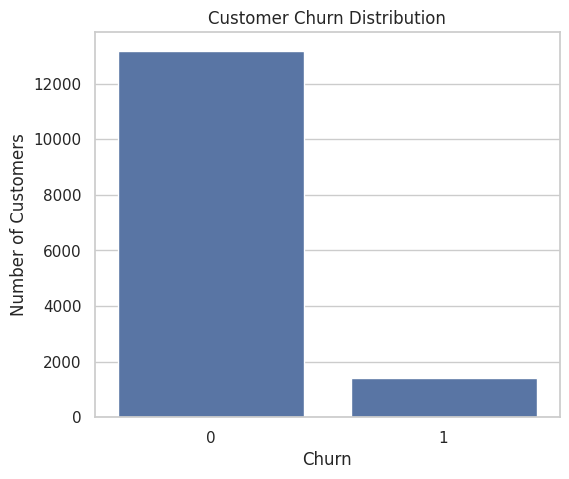

In [34]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=client_df,
    x='churn'
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

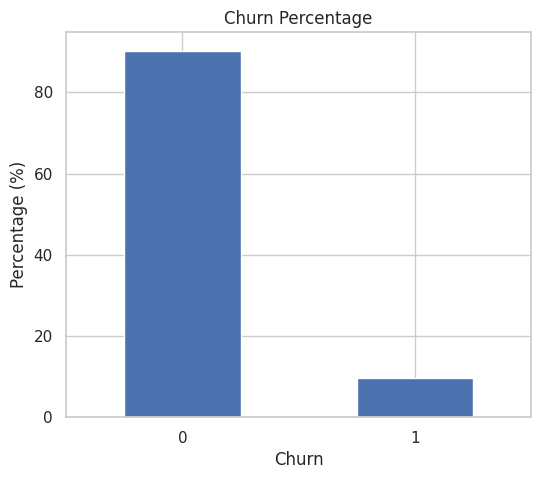

In [35]:
plt.figure(figsize=(6, 5))

churn_percentage.plot(
    kind='bar'
)

plt.title("Churn Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()

In [36]:
numeric_cols = client_df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols

['cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'pow_max',
 'churn']

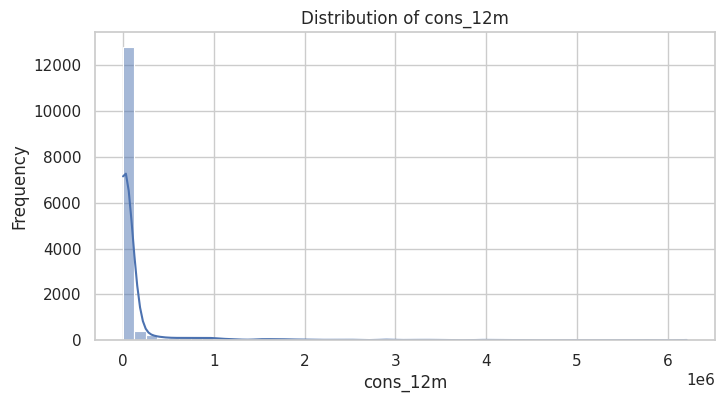

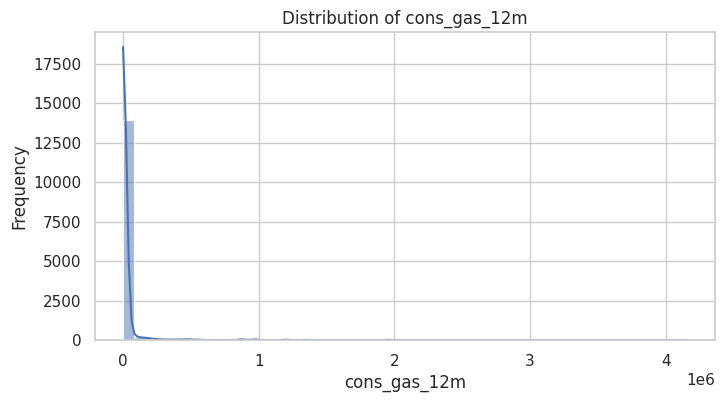

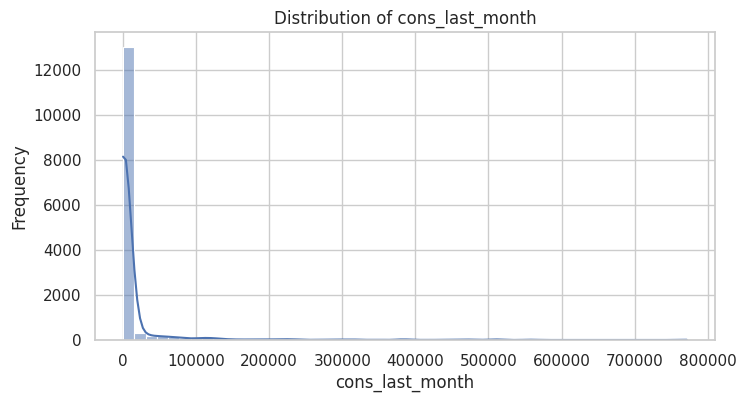

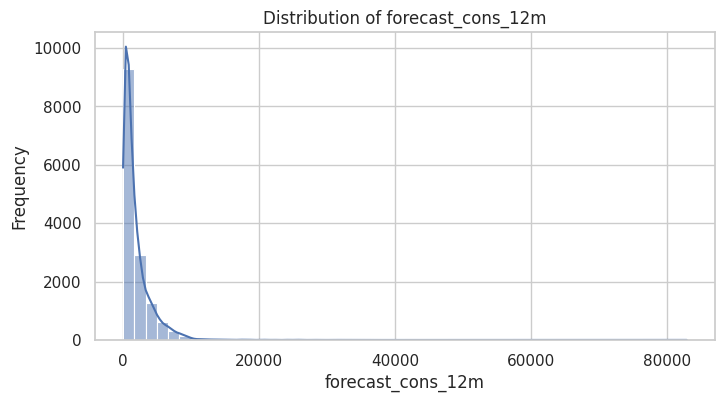

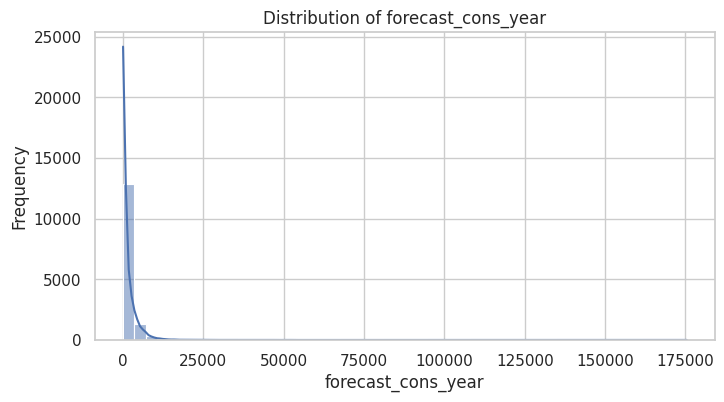

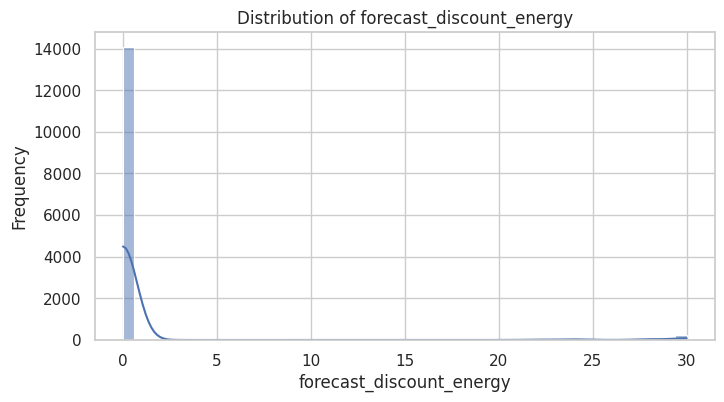

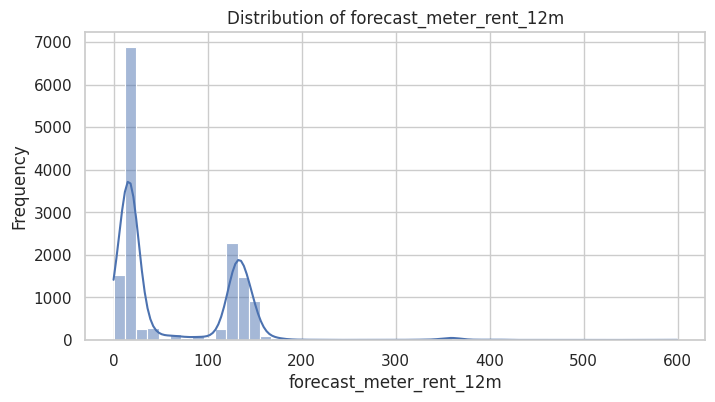

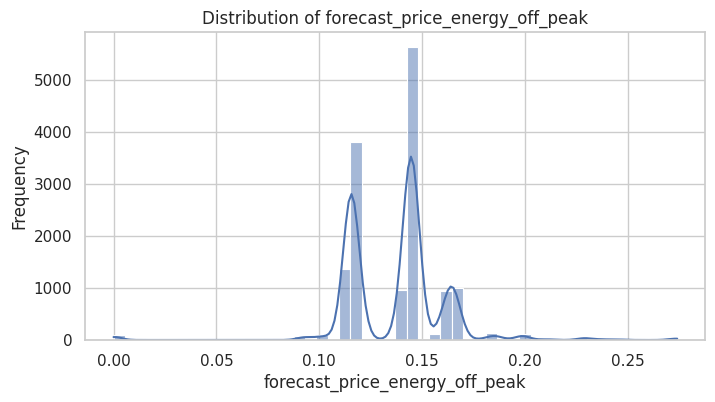

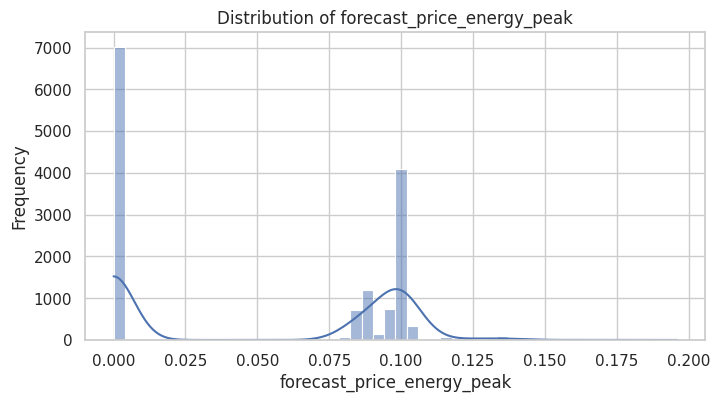

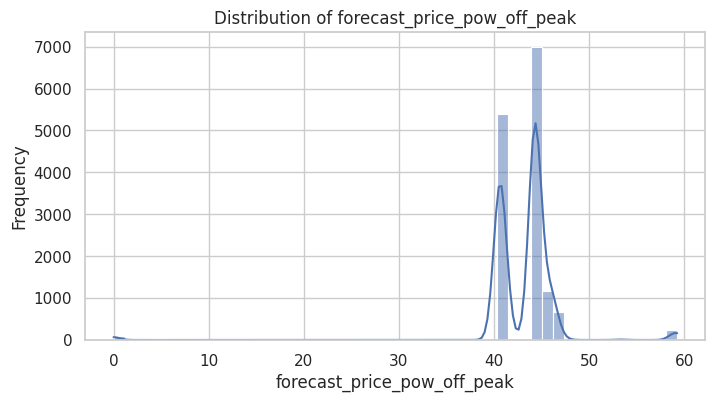

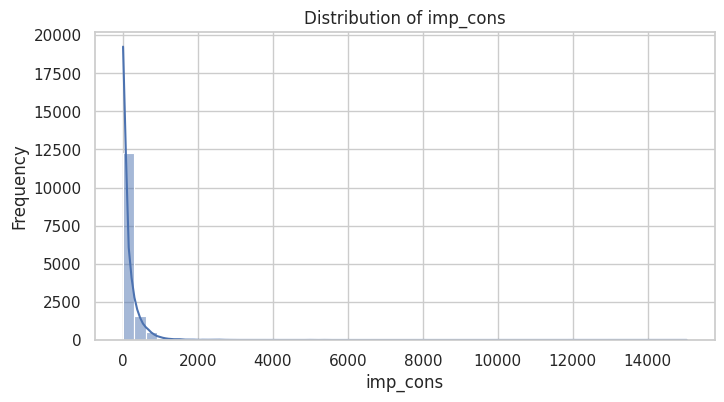

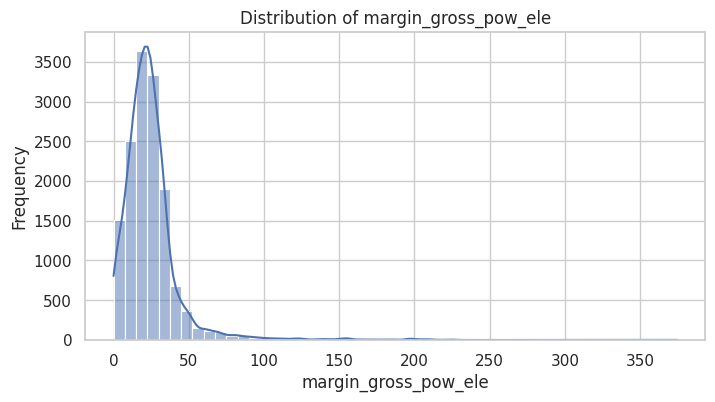

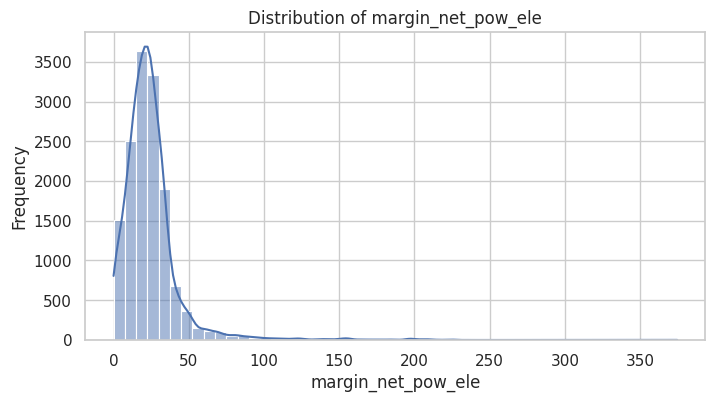

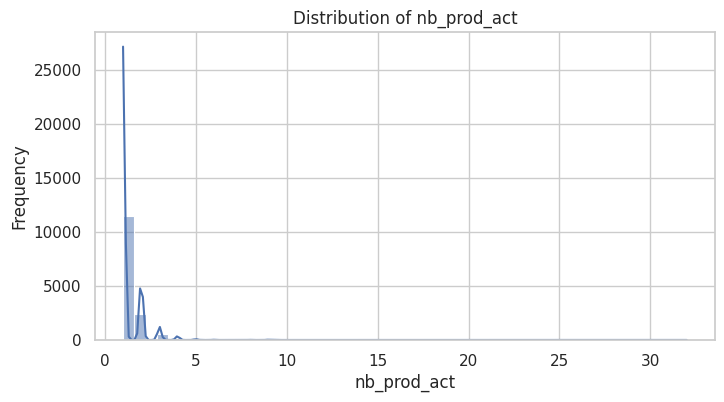

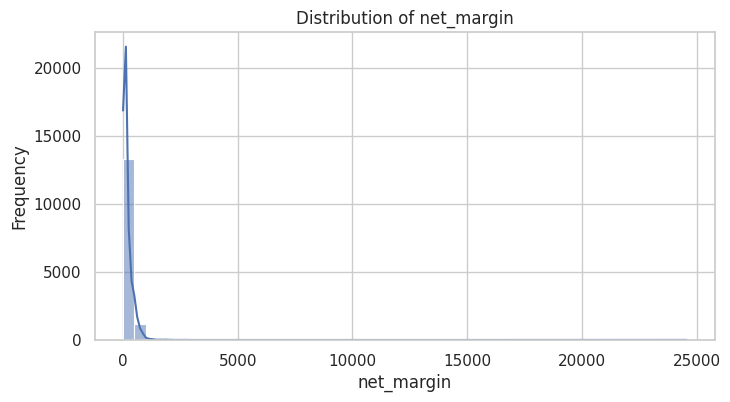

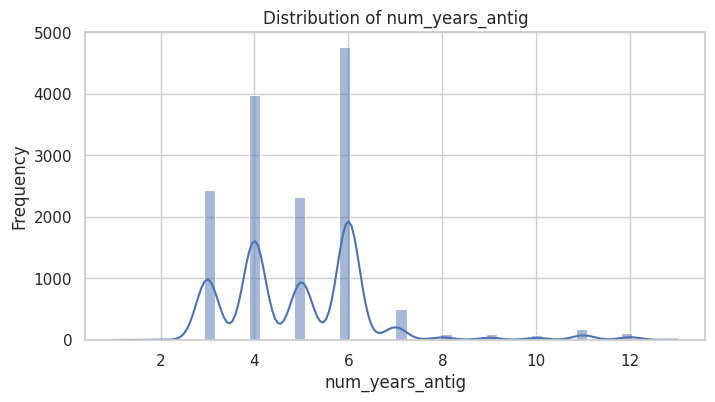

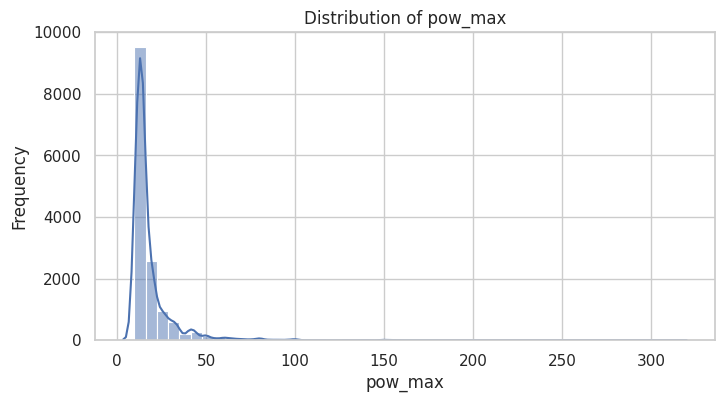

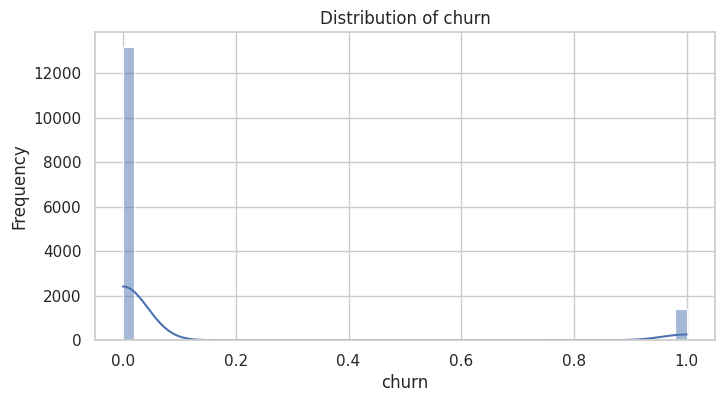

In [37]:
for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=client_df,
        x=col,
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

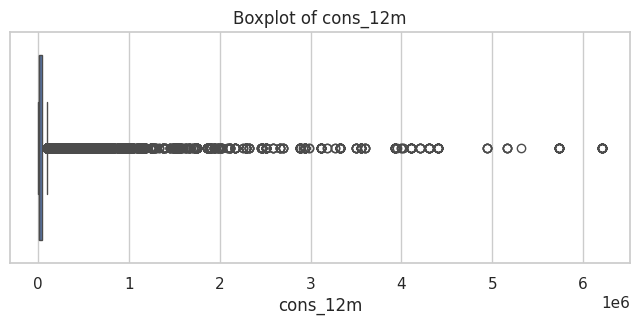

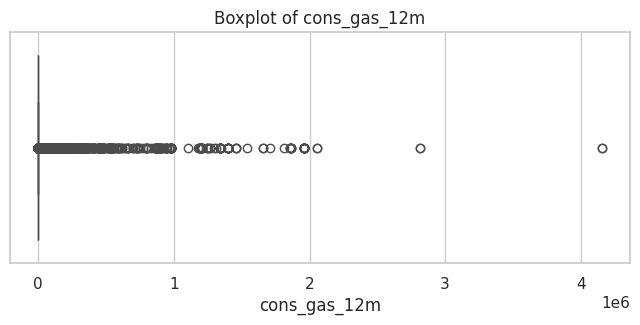

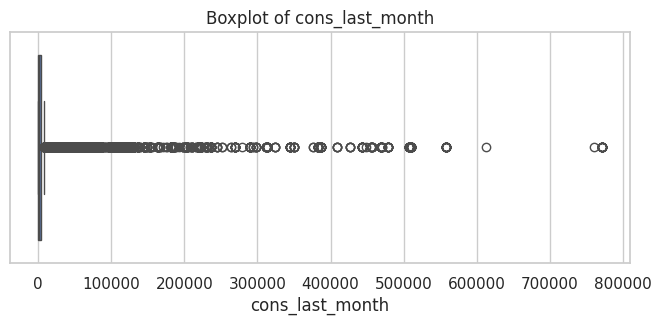

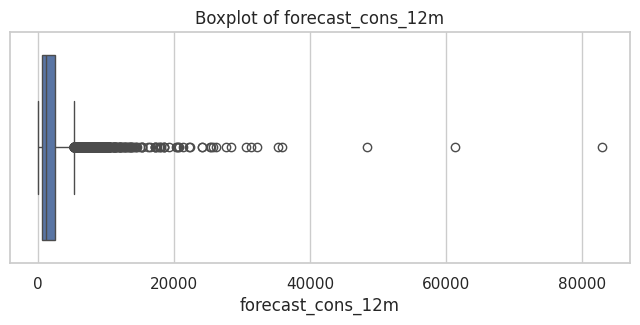

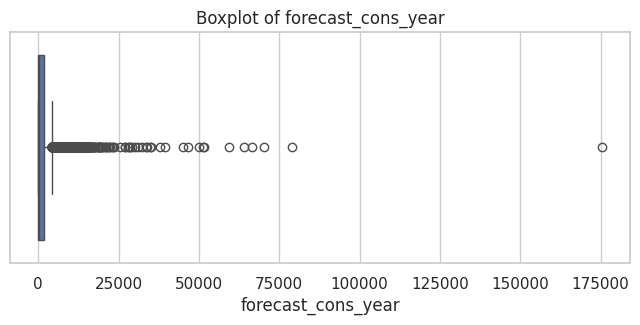

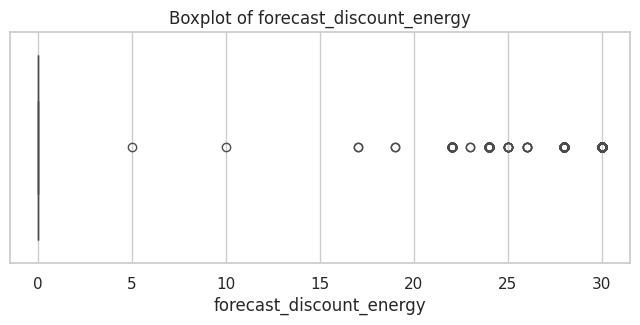

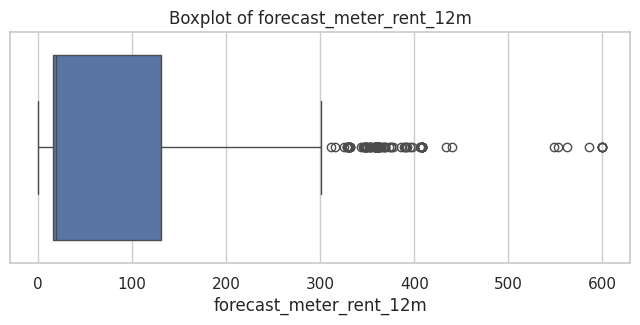

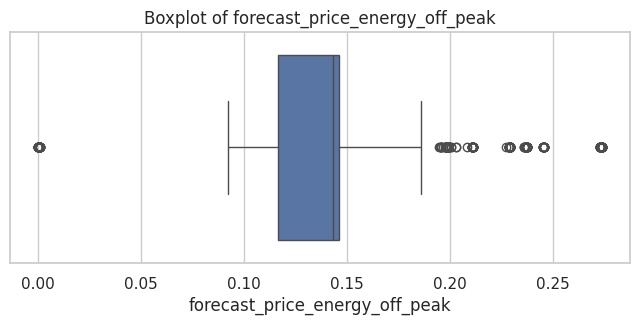

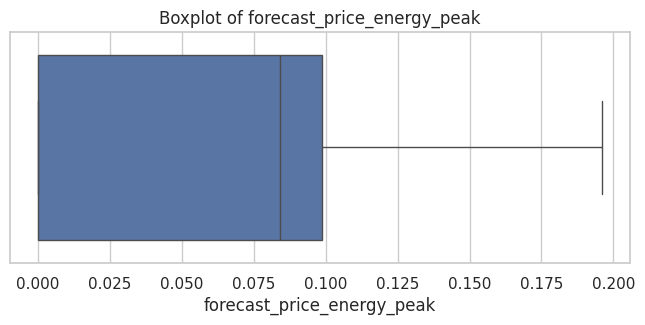

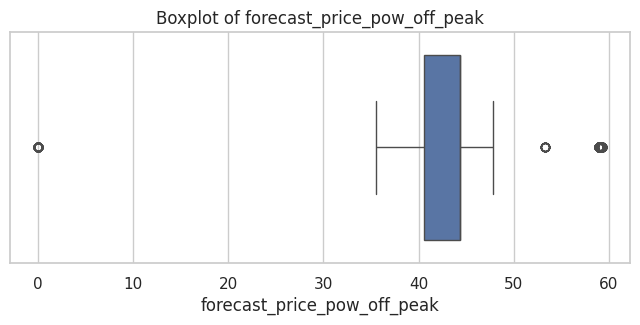

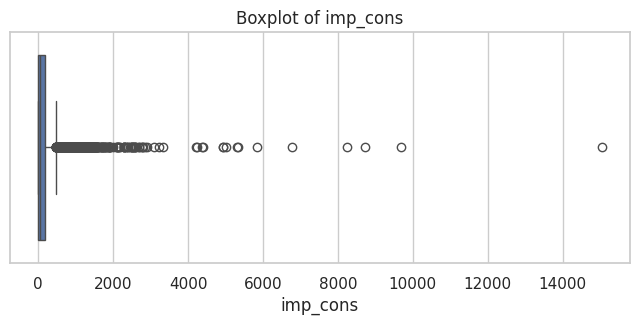

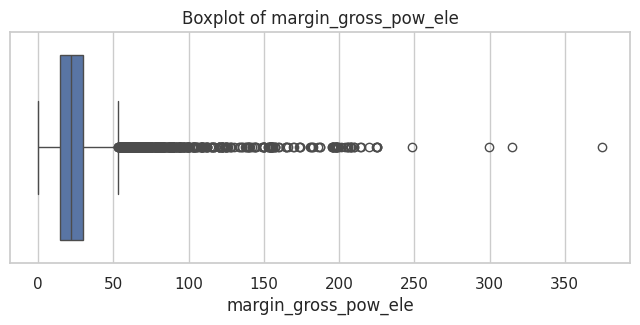

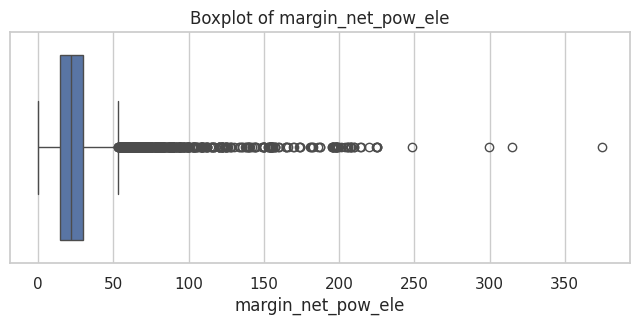

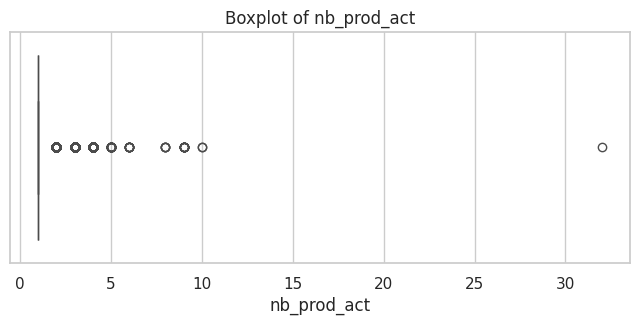

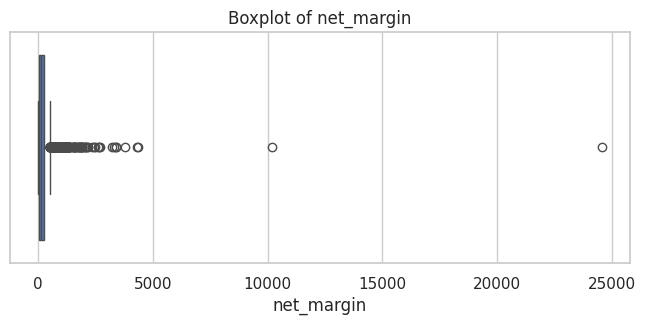

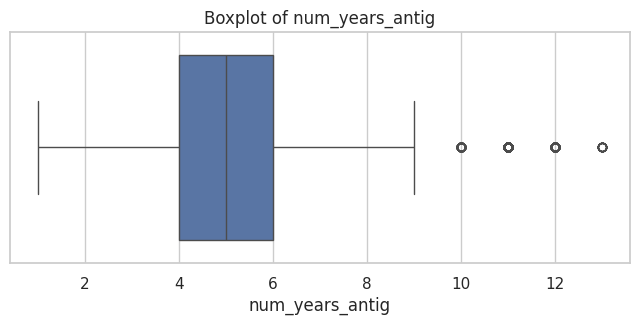

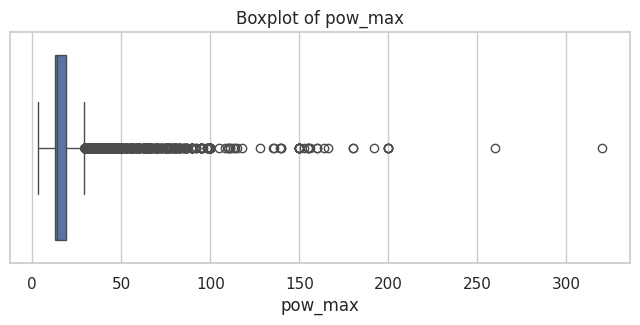

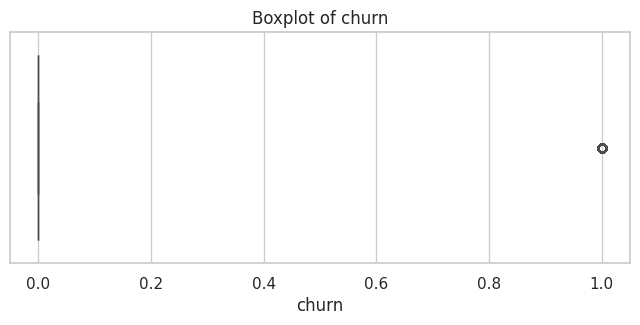

In [38]:
for col in numeric_cols:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=client_df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

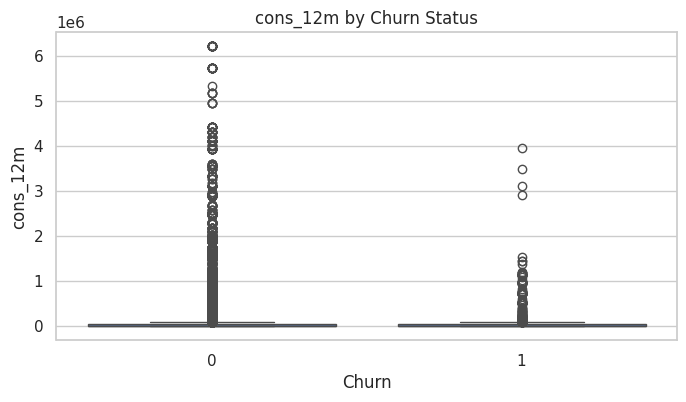

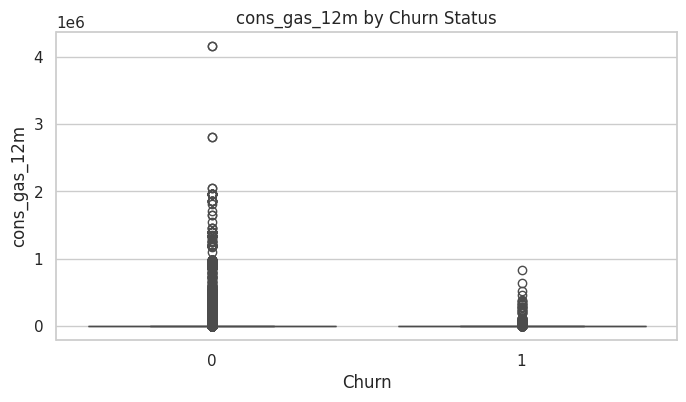

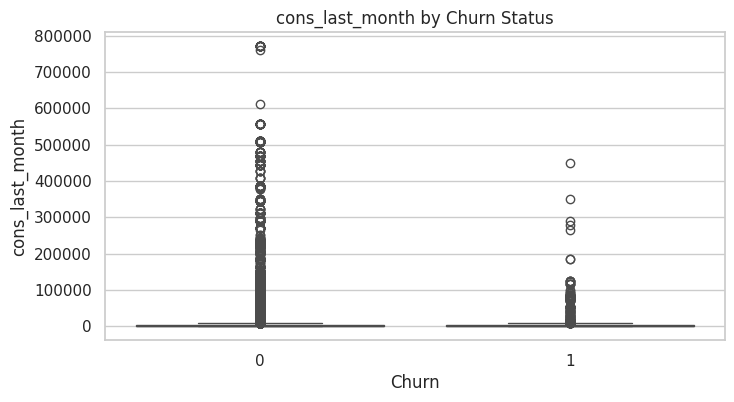

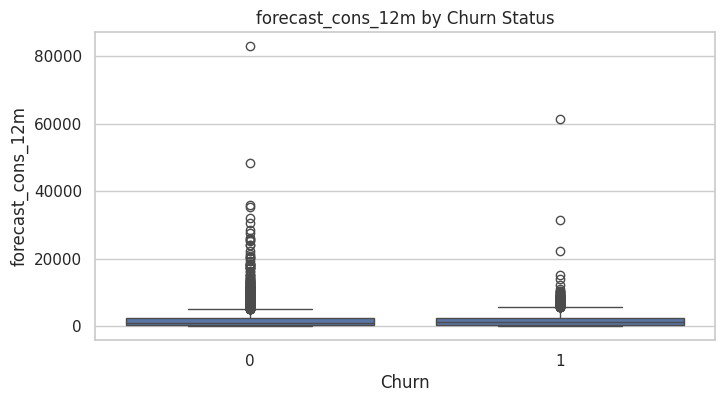

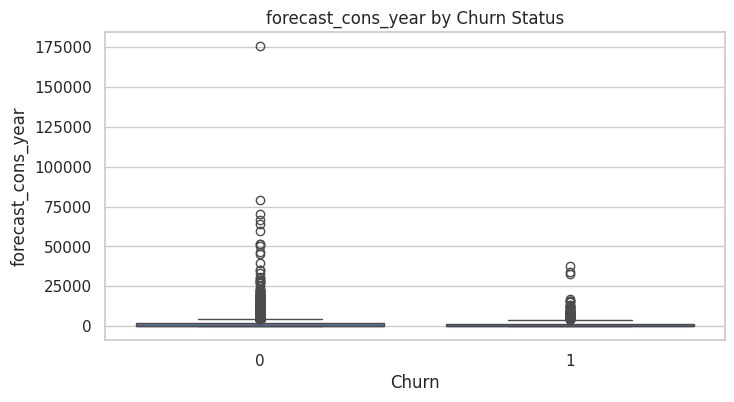

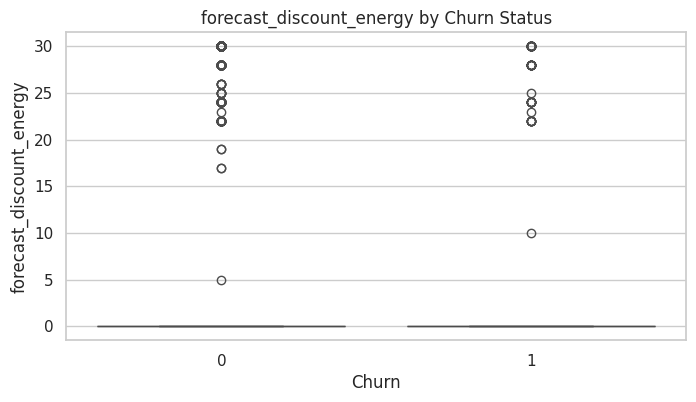

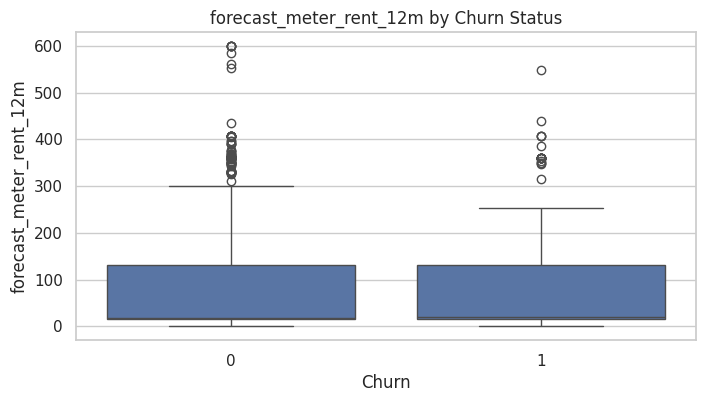

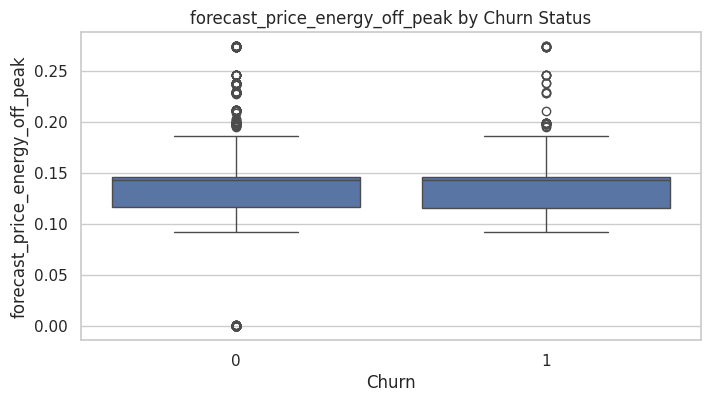

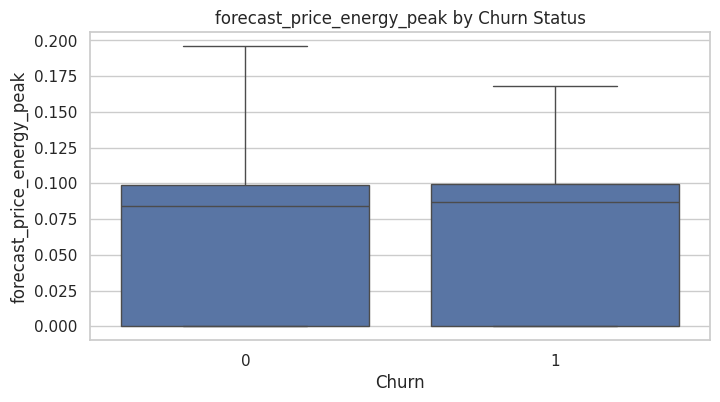

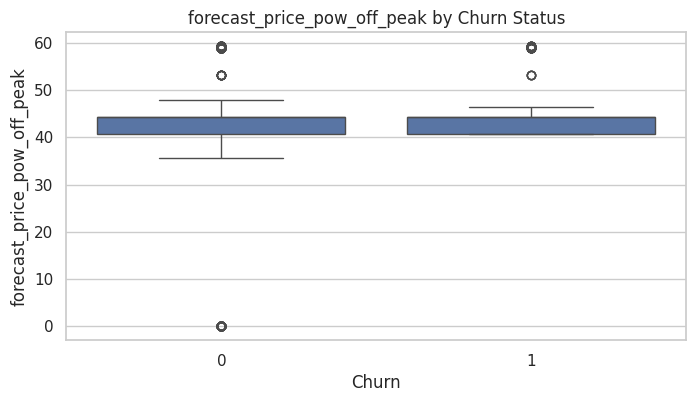

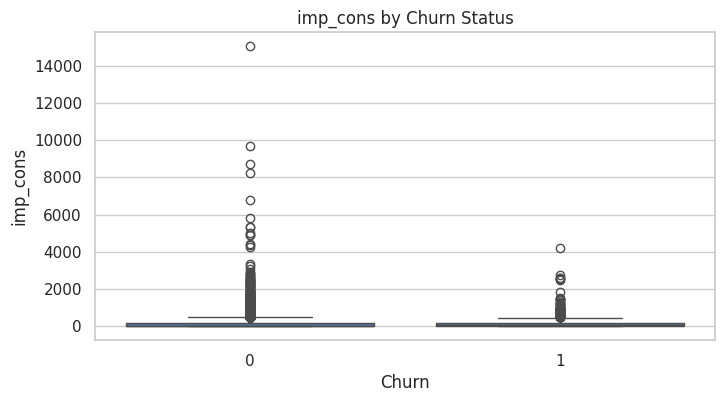

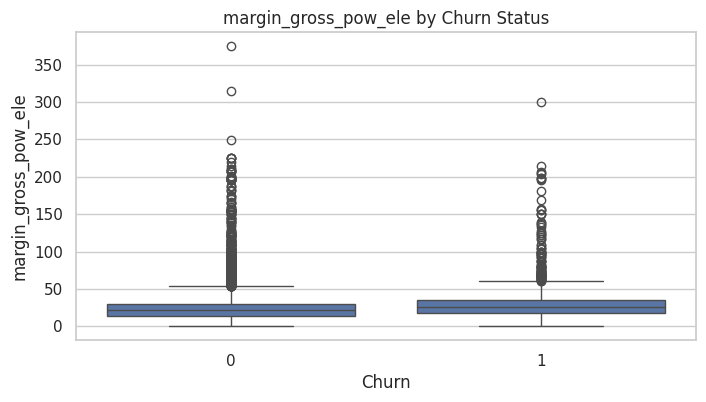

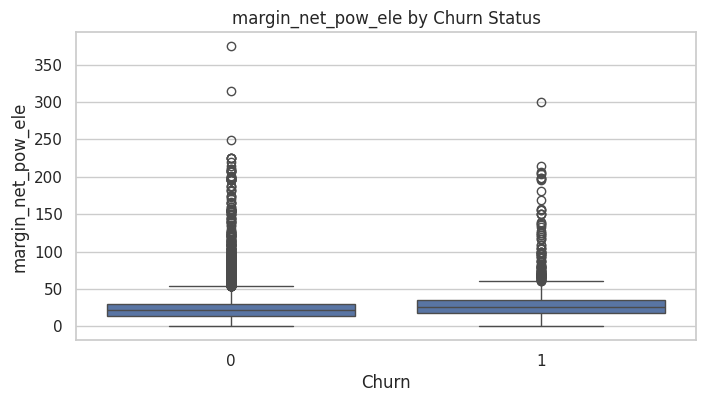

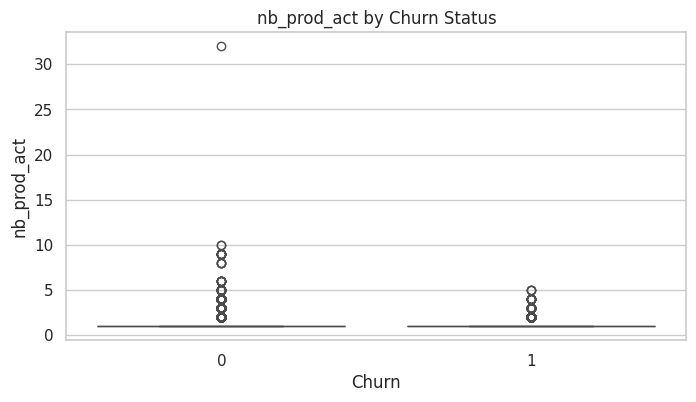

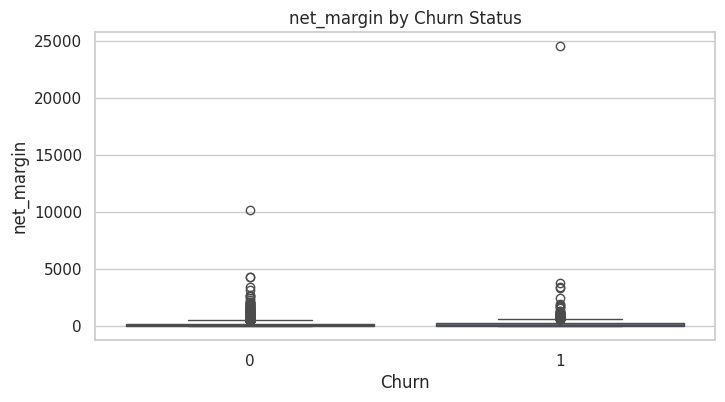

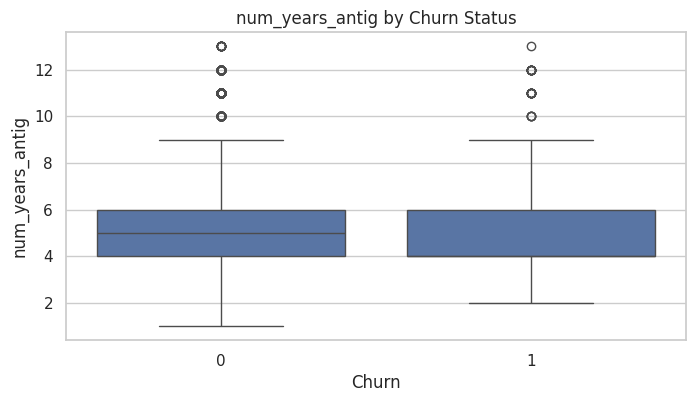

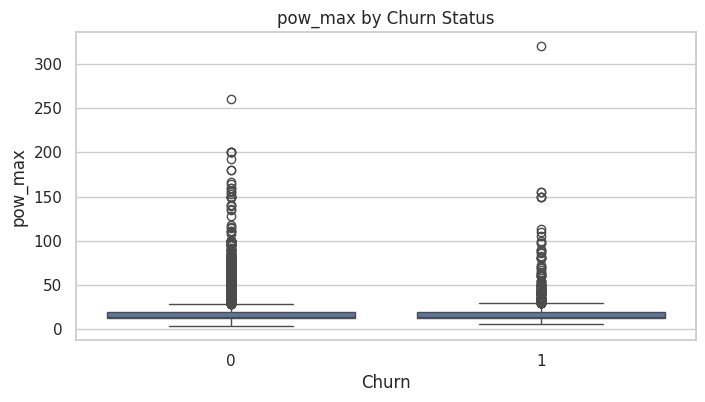

In [39]:
for col in numeric_cols:

    if col != 'churn':

        plt.figure(figsize=(8, 4))

        sns.boxplot(
            data=client_df,
            x='churn',
            y=col
        )

        plt.title(f"{col} by Churn Status")
        plt.xlabel("Churn")
        plt.ylabel(col)
        plt.show()

In [40]:
channel_churn = pd.crosstab(
    client_df['channel_sales'],
    client_df['churn'],
    normalize='index'
) * 100

display(channel_churn)

churn,0,1
channel_sales,,
MISSING,92.403,7.597
epumfxlbckeskwekxbiuasklxalciiuu,100.000,0.000
ewpakwlliwisiwduibdlfmalxowmwpci,91.601,8.399
fixdbufsefwooaasfcxdxadsiekoceaa,100.000,0.000
foosdfpfkusacimwkcsosbicdxkicaua,87.859,12.141
lmkebamcaaclubfxadlmueccxoimlema,94.411,5.589
sddiedcslfslkckwlfkdpoeeailfpeds,100.000,0.000
usilxuppasemubllopkaafesmlibmsdf,89.964,10.036


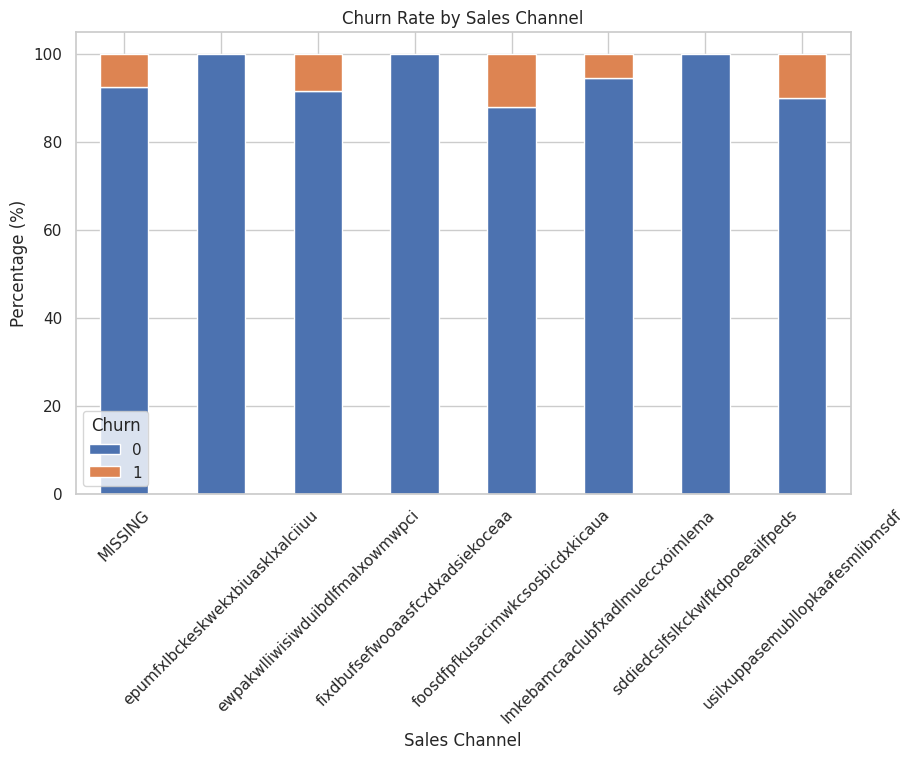

In [41]:
channel_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Churn Rate by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.xticks(rotation=45)
plt.show()

In [42]:
gas_churn = pd.crosstab(
    client_df['has_gas'],
    client_df['churn'],
    normalize='index'
) * 100

display(gas_churn)

churn,0,1
has_gas,,
f,89.946,10.054
t,91.814,8.186


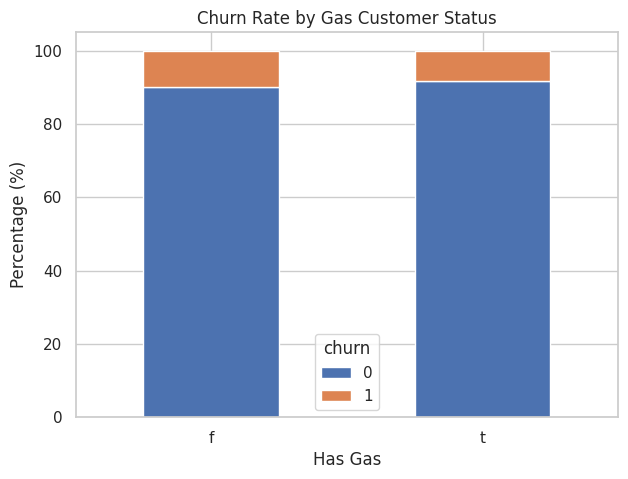

In [43]:
gas_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(7, 5)
)

plt.title("Churn Rate by Gas Customer Status")
plt.xlabel("Has Gas")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()

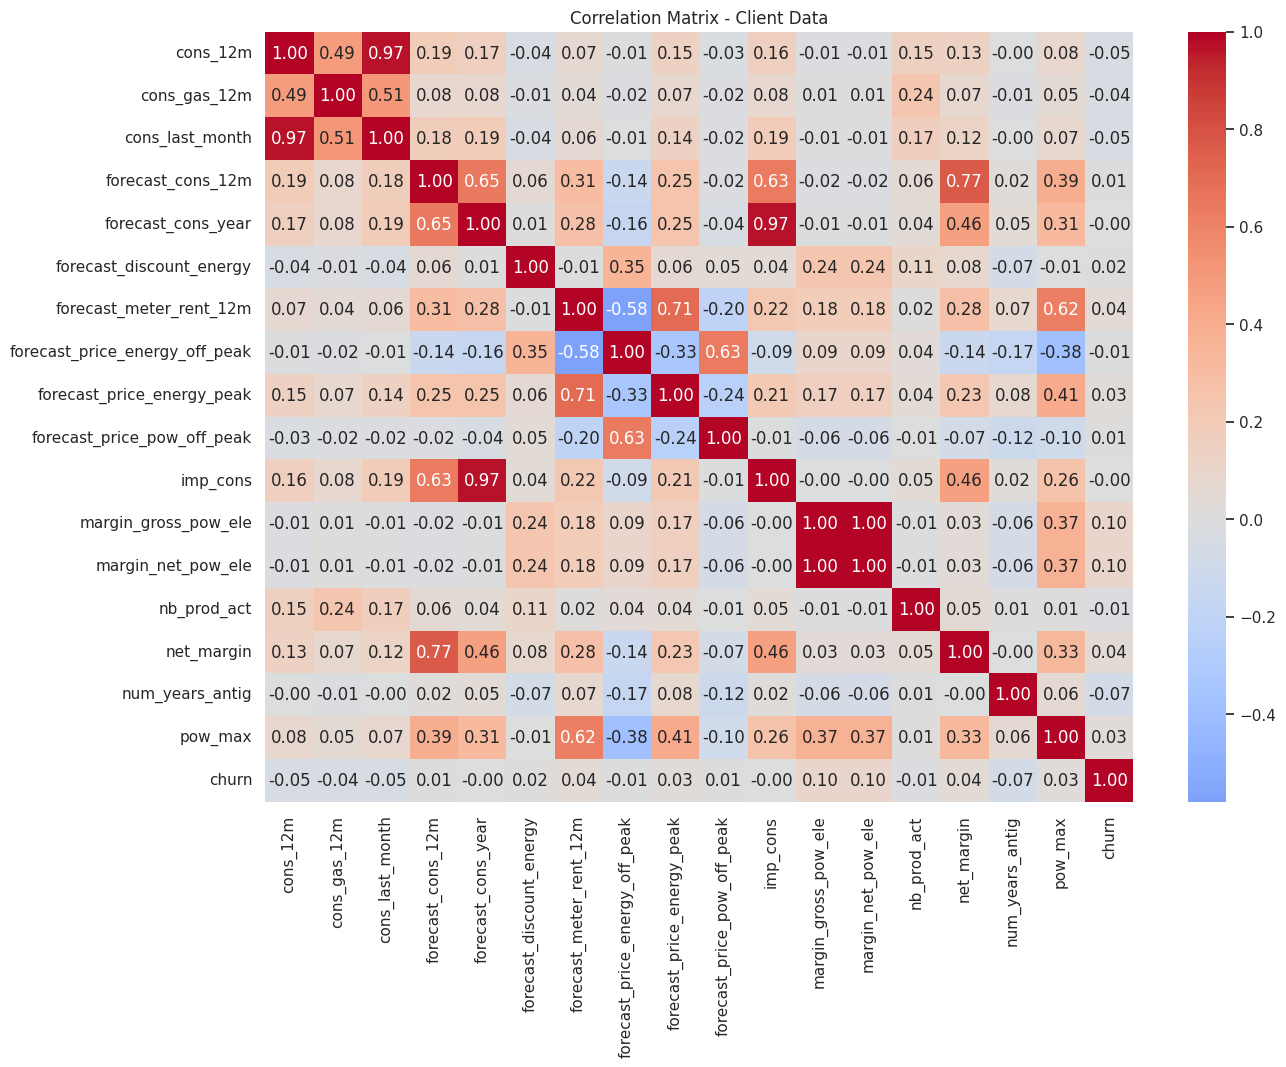

In [44]:
correlation_matrix = client_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix - Client Data")
plt.show()

In [45]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151,0.000,0.000,44.267,0.000,0.000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151,0.000,0.000,44.267,0.000,0.000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151,0.000,0.000,44.267,0.000,0.000
3,038af19179925da21a25619c5a24b745,2015-04-01,0.150,0.000,0.000,44.267,0.000,0.000
4,038af19179925da21a25619c5a24b745,2015-05-01,0.150,0.000,0.000,44.267,0.000,0.000


In [46]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161216,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.000,0.141,0.000,0.126,0.146,0.152,0.281,0.025
price_peak_var,193002.000,0.055,0.000,0.000,0.085,0.102,0.230,0.050
price_mid_peak_var,193002.000,0.030,0.000,0.000,0.000,0.073,0.114,0.036
price_off_peak_fix,193002.000,43.334,0.000,40.729,44.267,44.445,59.445,5.410
price_peak_fix,193002.000,10.623,0.000,0.000,0.000,24.340,36.491,12.842
price_mid_peak_fix,193002.000,6.410,0.000,0.000,0.000,16.226,17.458,7.774


In [47]:
price_numeric_cols = price_df.select_dtypes(
    include=np.number
).columns.tolist()

price_numeric_cols

['price_off_peak_var',
 'price_peak_var',
 'price_mid_peak_var',
 'price_off_peak_fix',
 'price_peak_fix',
 'price_mid_peak_fix']

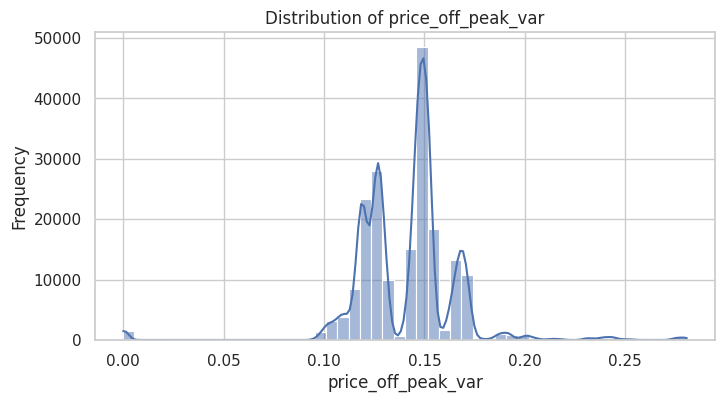

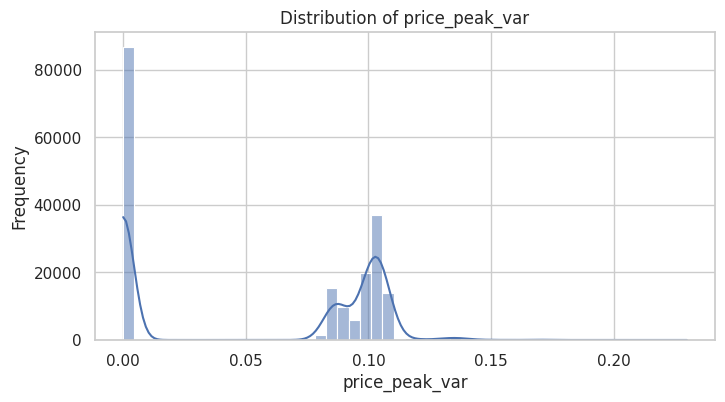

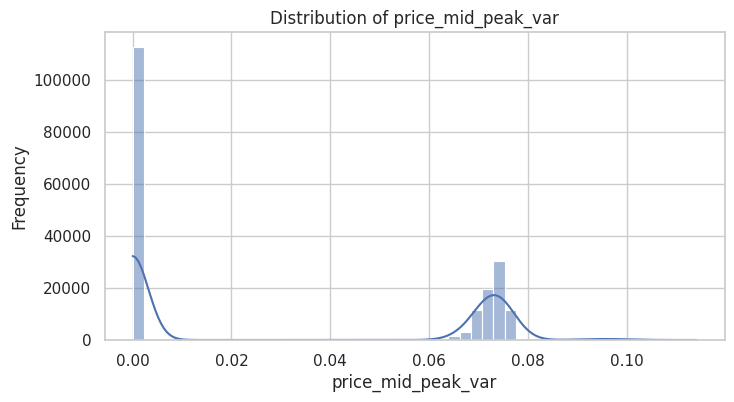

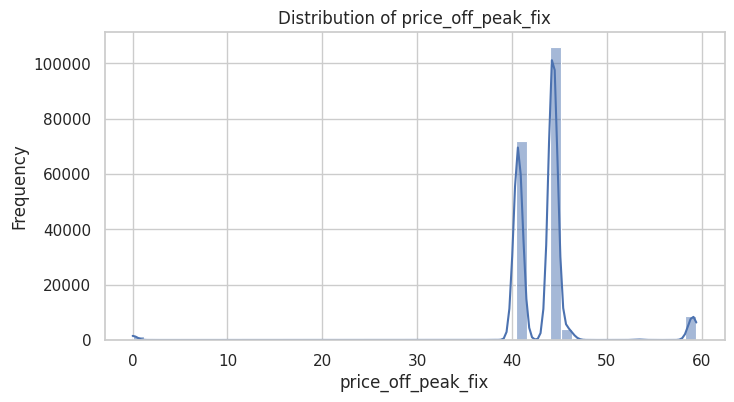

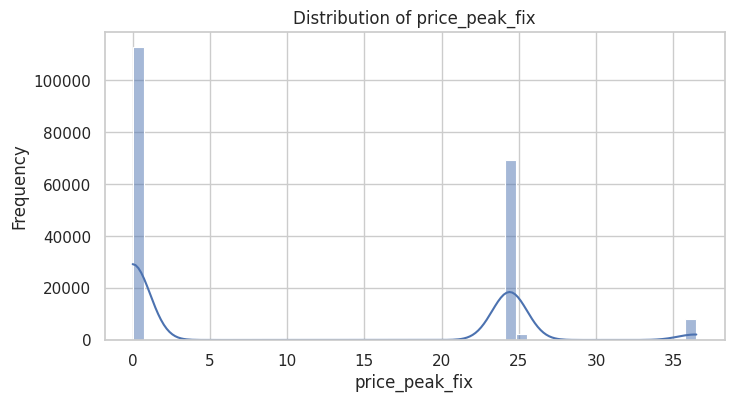

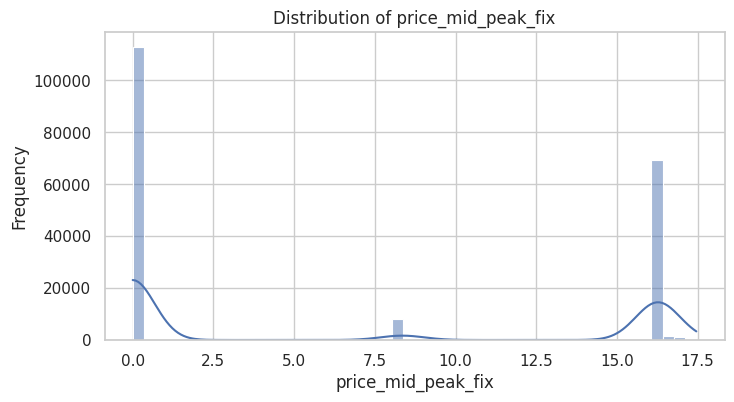

In [48]:
for col in price_numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=price_df,
        x=col,
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

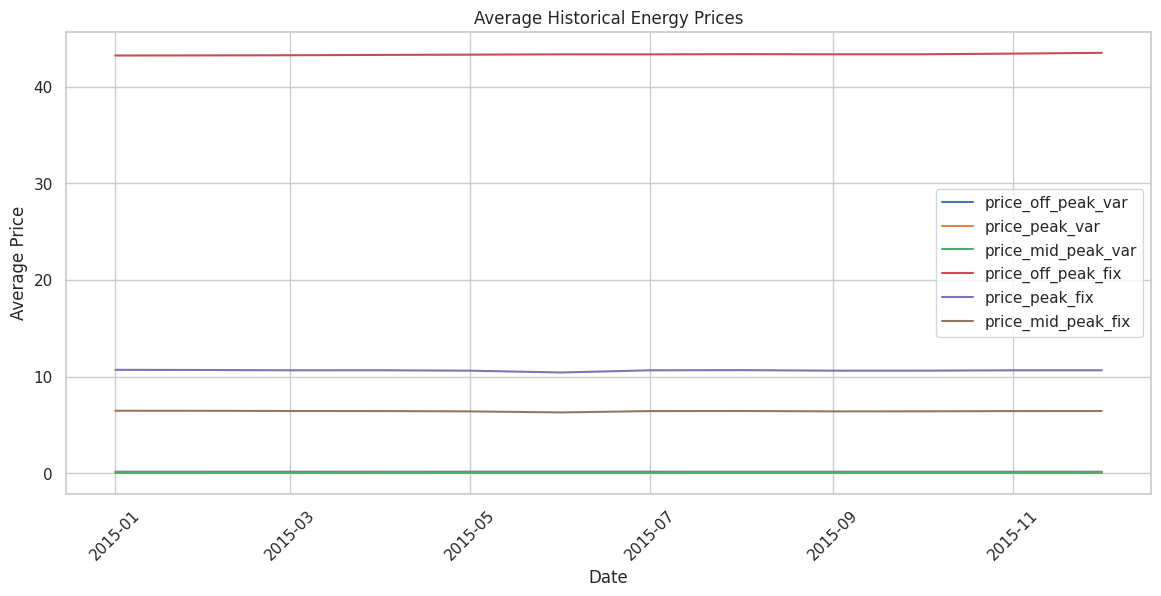

In [49]:
price_monthly = (
    price_df
    .groupby('price_date')[price_numeric_cols]
    .mean()
)

plt.figure(figsize=(14, 6))

for col in price_numeric_cols:
    plt.plot(
        price_monthly.index,
        price_monthly[col],
        label=col
    )

plt.title("Average Historical Energy Prices")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

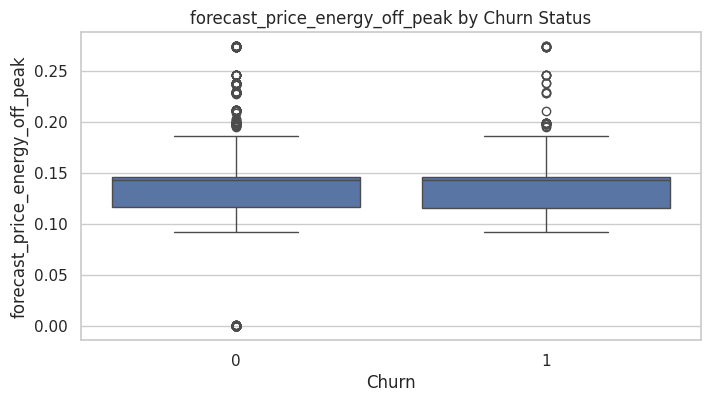

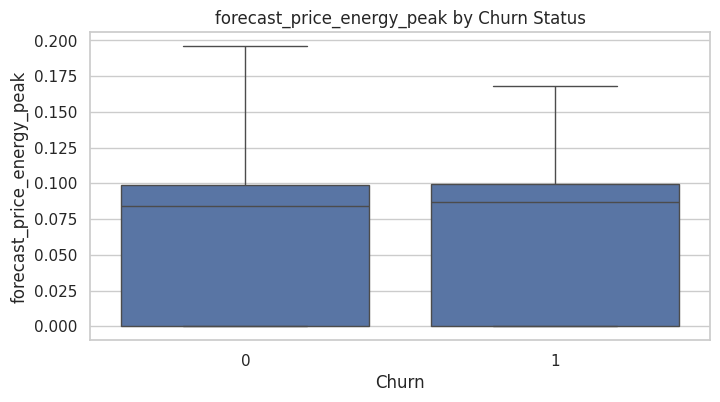

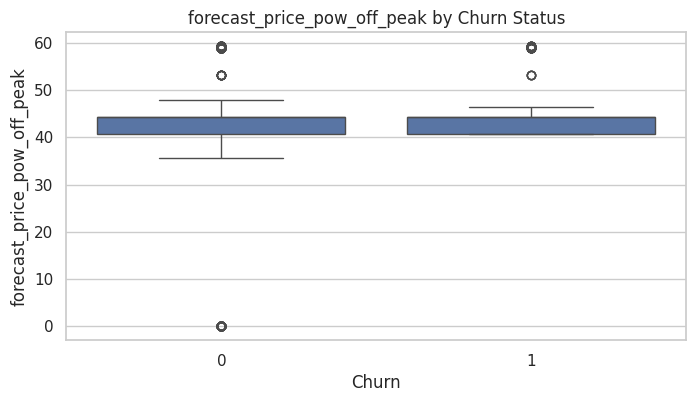

In [50]:
price_cols_client = [
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak',
    'forecast_price_pow_off_peak'
]

for col in price_cols_client:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=client_df,
        x='churn',
        y=col
    )

    plt.title(f"{col} by Churn Status")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [51]:
price_churn_summary = (
    client_df
    .groupby('churn')[price_cols_client]
    .mean()
    .T
)

display(price_churn_summary)

churn,0,1
forecast_price_energy_off_peak,0.137,0.136
forecast_price_energy_peak,0.050,0.055
forecast_price_pow_off_peak,43.108,43.332


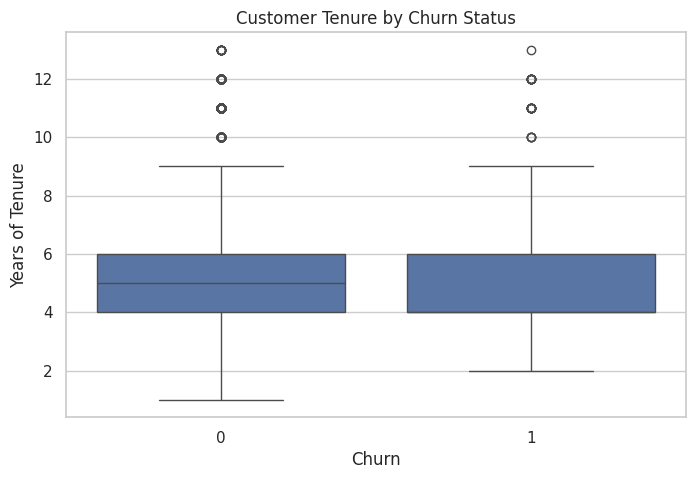

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=client_df,
    x='churn',
    y='num_years_antig'
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Years of Tenure")
plt.show()

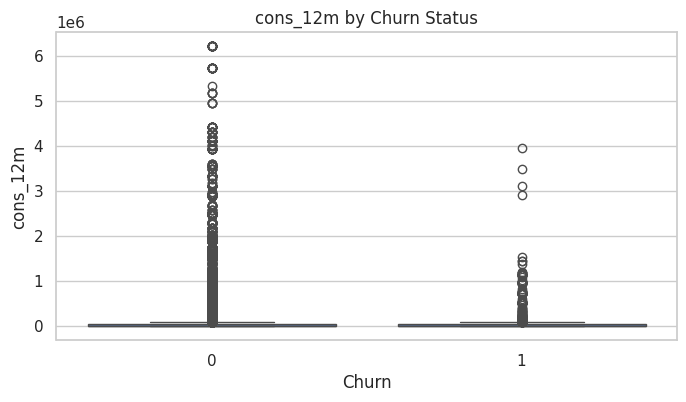

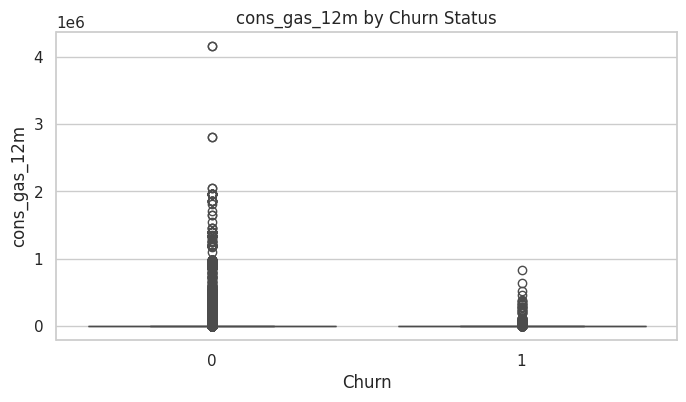

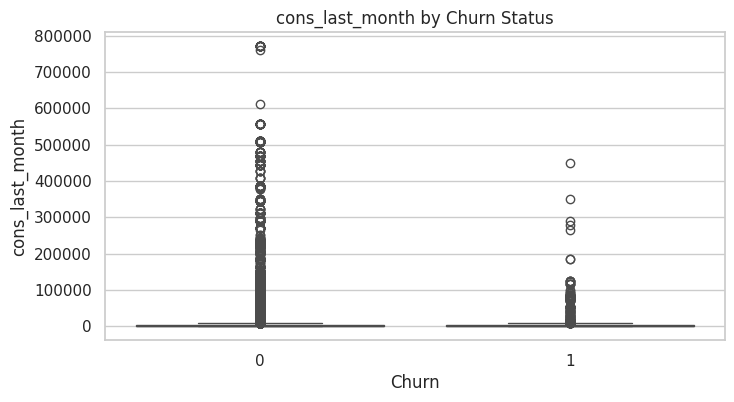

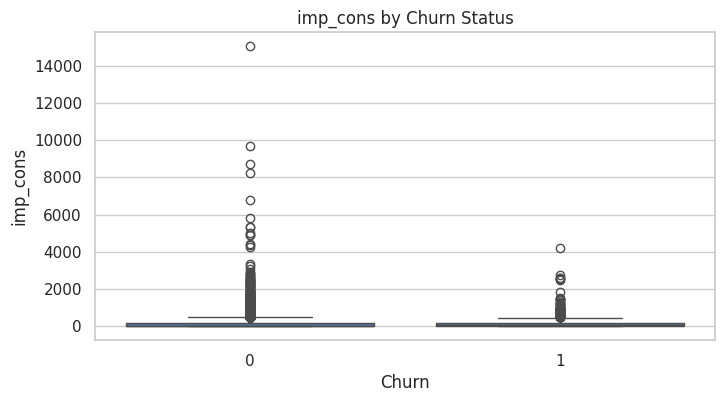

In [53]:
consumption_cols = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'imp_cons'
]

for col in consumption_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=client_df,
        x='churn',
        y=col
    )

    plt.title(f"{col} by Churn Status")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [54]:
eda_summary = pd.DataFrame({
    'Metric': [
        'Number of customers',
        'Number of price records',
        'Number of customer variables',
        'Number of price variables',
        'Churn rate (%)',
        'Missing client values',
        'Missing price values',
        'Duplicate client rows',
        'Unique customers in price data'
    ],
    'Value': [
        len(client_df),
        len(price_df),
        client_df.shape[1],
        price_df.shape[1],
        client_df['churn'].mean() * 100,
        client_df.isnull().sum().sum(),
        price_df.isnull().sum().sum(),
        client_df.duplicated().sum(),
        price_df['id'].nunique()
    ]
})

display(eda_summary)

,Metric,Value
0,Number of customers,14606.000
1,Number of price records,193002.000
2,Number of customer variables,26.000
3,Number of price variables,8.000
4,Churn rate (%),9.715
5,Missing client values,0.000
6,Missing price values,0.000
7,Duplicate client rows,0.000
8,Unique customers in price data,16096.000


## Key EDA Observations

- The client dataset contains customer-level information including consumption,
  contract dates, forecasted prices, margins, customer tenure and churn status.

- The pricing dataset contains historical variable and fixed pricing information
  recorded at different dates for customers.

- The churn variable is binary and represents whether a customer churned over
  the following three months.

- Descriptive statistics and distribution plots were used to understand the
  central tendency, spread and potential outliers in numerical variables.

- Categorical variables were examined using frequency and churn-rate analysis.

- Numerical variables were compared between churned and retained customers to
  identify potential differences.

- Historical price variables were explored to understand their distributions
  and changes over time.

- Price-related variables were specifically compared against churn to provide
  an initial assessment of the price-sensitivity hypothesis.

- These findings are exploratory and do not establish causality. Further
  statistical analysis and modelling would be required to determine whether
  price is a significant independent driver of churn.